In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer  # Importa PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss


# Caricare i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Stampa i nomi delle colonne per verificare
#print("Colonne nel DataFrame:", data.columns)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])  # Rimuovi filename e label
y = data['label']  # Etichette

# Suddividere il dataset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]

print('FINITO')

FINITO


In [ ]:
for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Creare il modello SVM
    model = SVC(kernel='linear')
    model.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test)

    # Calcolare l'accuratezza
    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-score: {f1:.2f}')
    print(f'F2-score: {f2:.2f}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.72
Precision: 0.73
Recall: 0.74
F1-score: 0.72
F2-score: 0.73
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.69
Precision: 0.71
Recall: 0.71
F1-score: 0.70
F2-score: 0.70
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.64
Precision: 0.66
Recall: 0.66
F1-score: 0.65
F2-score: 0.65
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.72
Precision: 0.73
Recall: 0.73
F1-score: 0.72
F2-score: 0.73
------------------------------------------------------------


grid search con kernel rbf

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

param_grid = {
    'C': [1, 10],
    'gamma': ['scale'] + [0.1,1],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

I Migliori parametri trovati sono: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [5]:
for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Creare il modello SVM
    model = SVC(C=10, gamma='scale', kernel='rbf')
    model.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test)

    # Calcolare l'accuratezza
    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
   # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.7650
Precision: 0.7750
Recall: 0.7756
F1-score: 0.7694
F2-score: 0.7720
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.7900
Precision: 0.7945
Recall: 0.8007
F1-score: 0.7882
F2-score: 0.7934
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.7750
Precision: 0.7830
Recall: 0.7892
F1-score: 0.7779
F2-score: 0.7825
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.8100
Precision: 0.8090
Recall: 0.8229
F1-score: 0.8093
F2-score: 0.8159
------------------------------------------------------------


grid search con kernel polinomiale

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 'auto'] + [0.01],
    'kernel': ['poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

I Migliori parametri trovati sono: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}


In [7]:

for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Creare il modello SVM
    model = SVC(C=10, gamma='auto', kernel='poly')
    model.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test)

    # Calcolare l'accuratezza
    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'F1-score: {f1:.3f}')
    print(f'F2-score: {f2:.3f}')
   # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')


           Scaler: RobustScaler()
Accuratezza: 0.660
Precision: 0.729
Recall: 0.662
F1-score: 0.666
F2-score: 0.657
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.765
Precision: 0.796
Recall: 0.775
F1-score: 0.779
F2-score: 0.775
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.500
Precision: 0.542
Recall: 0.528
F1-score: 0.499
F2-score: 0.511
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.765
Precision: 0.794
Recall: 0.775
F1-score: 0.778
F2-score: 0.775
------------------------------------------------------------


Accuratezza per ogni fold: [0.7, 0.72, 0.8, 0.72, 0.75, 0.71, 0.77, 0.77, 0.65, 0.69]
Accuratezza media dopo K-Fold: 0.7280
Precisione media dopo K-Fold: 0.7398
Recall media dopo K-Fold: 0.7280
F1-score medio dopo K-Fold: 0.7254
F2-score medio dopo K-Fold: 0.7251

Feature selezionate dal Lasso: ['length', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var']
In

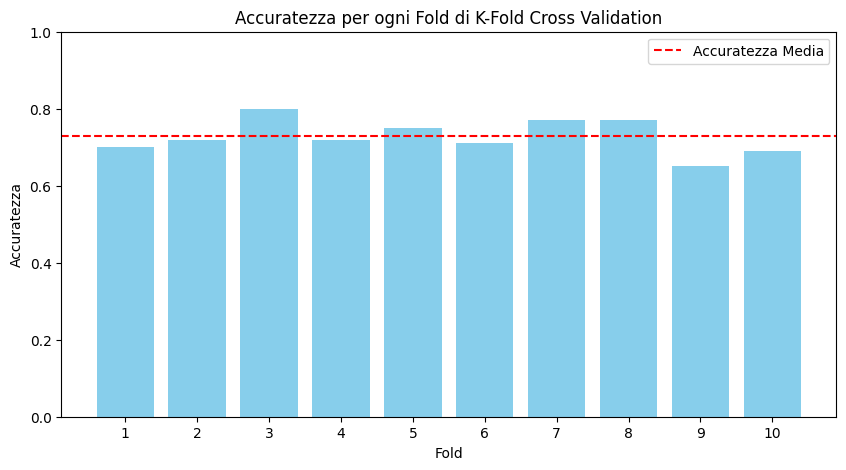

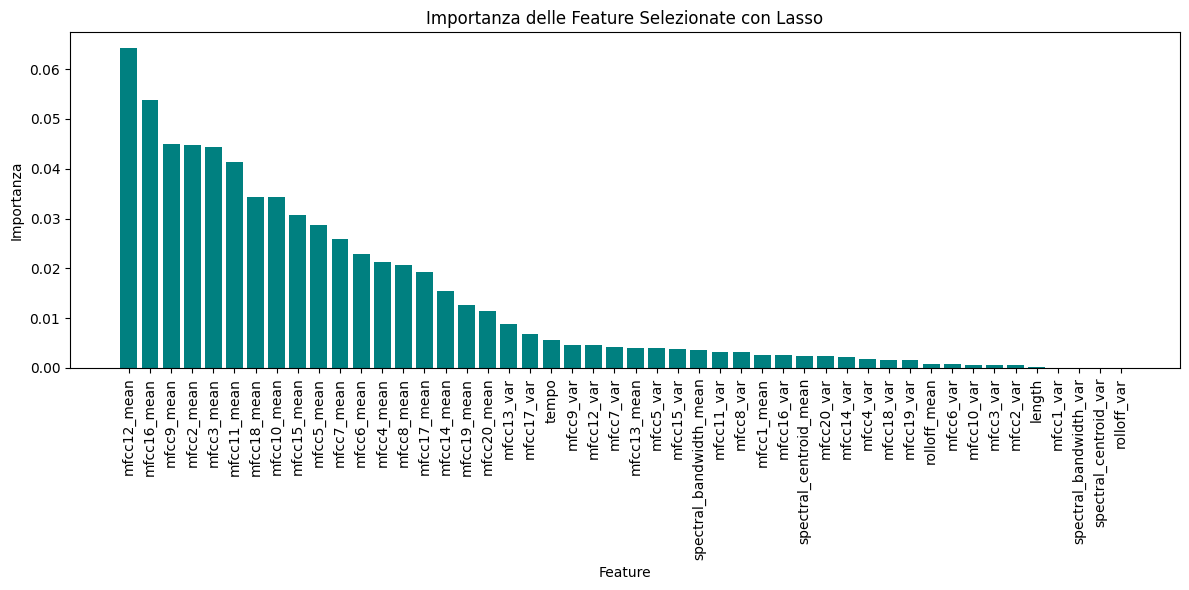

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
precisions = []
recalls = []
f1_scores = []
f2_scores = []
importances_dict = {}

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X, y_encoded):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.1, max_iter=10000)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Standardizza le caratteristiche selezionate
    scaler = StandardScaler()
    X_train_selected = scaler.fit_transform(X_train_selected)
    X_test_selected = scaler.transform(X_test_selected)

    # Creare il modello SVM
    model = SVC(C=10, gamma='scale', kernel='rbf')
    model.fit(X_train_selected, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test_selected)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')

    # Aggiungere le metriche alla lista
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    f2_scores.append(f2)

    # Salvare le importanze con il nome della feature
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]
        if feature_name in importances_dict:
            importances_dict[feature_name].append(abs(lasso.coef_[feature_index]))
        else:
            importances_dict[feature_name] = [abs(lasso.coef_[feature_index])]

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
print(f"Precisione media dopo K-Fold: {np.mean(precisions):.4f}")
print(f"Recall media dopo K-Fold: {np.mean(recalls):.4f}")
print(f"F1-score medio dopo K-Fold: {np.mean(f1_scores):.4f}")
print(f"F2-score medio dopo K-Fold: {np.mean(f2_scores):.4f}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print("Indice di feature selezionate:",(selected_features))
print("Numero di feature selezionate:", len(selected_feature_names))

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze per fold
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature Selezionate con Lasso')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
